In [1]:
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from coordinate_conversions import *

In [4]:
import sys
import pandas as pd
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import *
from plotting import *
from get_LrLx_data import *

# Coordinates

In [2]:
# https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Aql%20X-1
ra_deg, dec_deg = sexagesimal_to_degrees("19:11:16.0571313336", "00:35:05.868232692")
print("RA (deg): ", ra_deg)
print("Dec (deg): ", dec_deg)

RA (deg):  287.81690471389
Dec (deg):  0.5849633979700001


In [3]:
icrs_to_galactic(ra_deg = 287.81690471389, dec_deg = 0.5849633979700001)

Galactic l: 35.71847385573711
Galactic b: -4.143198842288852


# Get Data

In [7]:
source_df, obs_df, radio_df, xray_df = read_data("../DATA/Aquila X-1.txt")

Aquila X-1
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


In [8]:
radio_df

,name,blockID,band,t_radio,dt_radio,Rphase,Rstate,Fr,Fr_unc,local_rms,alpha,alpha_unc,Fr_uplim_bool
0,Aquila X-1,1598130064,L,59083.92535,0.0102,NaN,HS,0.1950,0.027768,20.0,NaN,NaN,False
1,Aquila X-1,1598801721,L,59091.70035,0.0102,NaN,HS,0.1710,0.034090,19.0,NaN,NaN,False
2,Aquila X-1,1726920975,L,60574.59674,0.0102,NaN,HS,0.0880,0.025384,18.0,NaN,NaN,False
3,Aquila X-1,1727610136,L,60582.56081,0.0102,NaN,IMS,0.3880,0.027863,23.0,NaN,NaN,False
4,Aquila X-1,1728213242,L,60589.54125,0.0102,NaN,SS,0.0720,0.024000,24.0,NaN,NaN,True
5,Aquila X-1,1728903370,L,60597.54484,0.0102,NaN,SS,0.0810,0.027000,27.0,NaN,NaN,True
6,Aquila X-1,1729424896,L,60603.56631,0.0102,NaN,SS,0.0690,0.023000,23.0,NaN,NaN,True
7,Aquila X-1,1729943660,L,60609.55559,0.0102,NaN,IMS,0.1300,0.027771,23.0,NaN,NaN,False
8,Aquila X-1,1730455875,L,60615.48348,0.0102,NaN,IMS,0.1590,0.048654,25.0,NaN,NaN,False
9,Aquila X-1,1731232274,L,60624.48392,0.0102,NaN,HS,0.0600,0.020000,20.0,NaN,NaN,True


In [9]:
xray_df

,name,obsID,t_xray,dt_xray,Xphase,Xstate,Fx,Fx_unc_l,Fx_unc_u,model,fit_stat,Fx_uplim_bool
0,Aquila X-1,33665136,59081.68788,0.006932,rise,HS,5.248000e-10,5.325494e-11,5.328065e-11,tbabs*pegpwrlw,NaN,False
1,Aquila X-1,33665137,59082.82182,0.008669,rise,HS,1.200000e-09,1.206186e-10,1.206257e-10,tbabs*pegpwrlw,NaN,False
2,Aquila X-1,33665138,59083.95482,0.008670,rise,HS,1.864000e-09,1.870018e-10,1.870147e-10,tbabs*pegpwrlw,NaN,False
3,Aquila X-1,33665139,59084.95173,0.013885,rise,HS,1.241000e-09,1.244835e-10,1.244845e-10,tbabs*pegpwrlw,NaN,False
4,Aquila X-1,33665140,59085.80990,0.013886,rise,HS,1.136000e-09,1.139549e-10,1.139604e-10,tbabs*pegpwrlw,NaN,False
5,Aquila X-1,33665142,59086.93782,0.009893,rise,HS,1.400000e-09,1.405133e-10,1.405211e-10,tbabs*pegpwrlw,NaN,False
6,Aquila X-1,33665147,59094.43927,0.000077,rise,IMS,5.608000e-09,7.177748e-10,6.690110e-10,tbabs*cflux*(diskbb+bbodyrad),NaN,False
7,Aquila X-1,33665148,59097.42886,0.393053,rise,IMS,8.175000e-09,8.193067e-10,8.193892e-10,tbabs*cflux*(diskbb+bbodyrad),NaN,False
8,Aquila X-1,35323053,60572.97309,0.011259,NaN,HS,9.954000e-10,1.008209e-10,1.008273e-10,tbabs*cflux*(powerlaw+bbodyrad),NaN,False
9,Aquila X-1,35323055,60578.38656,0.201082,NaN,HS,2.943000e-09,2.963002e-10,2.962392e-10,tbabs*cflux*(powerlaw+bbodyrad),NaN,False


# Light Curves

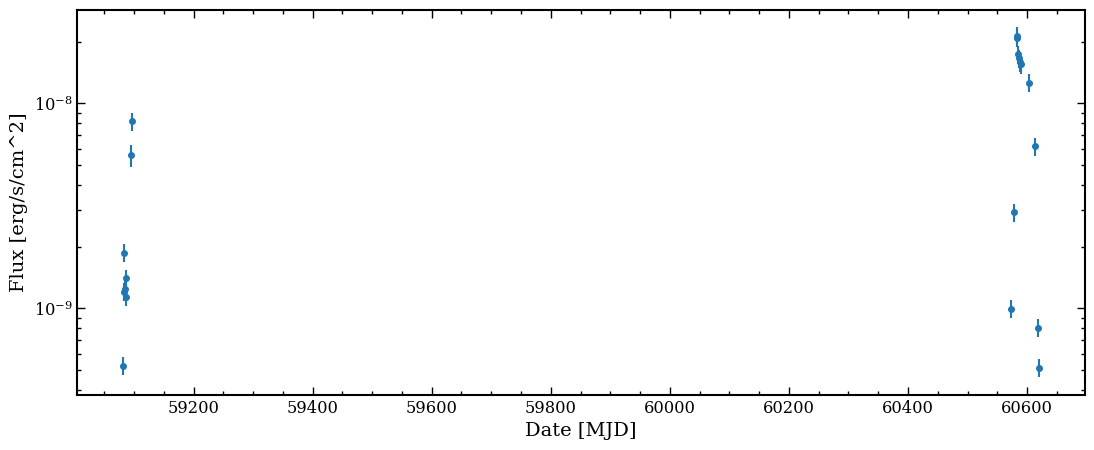

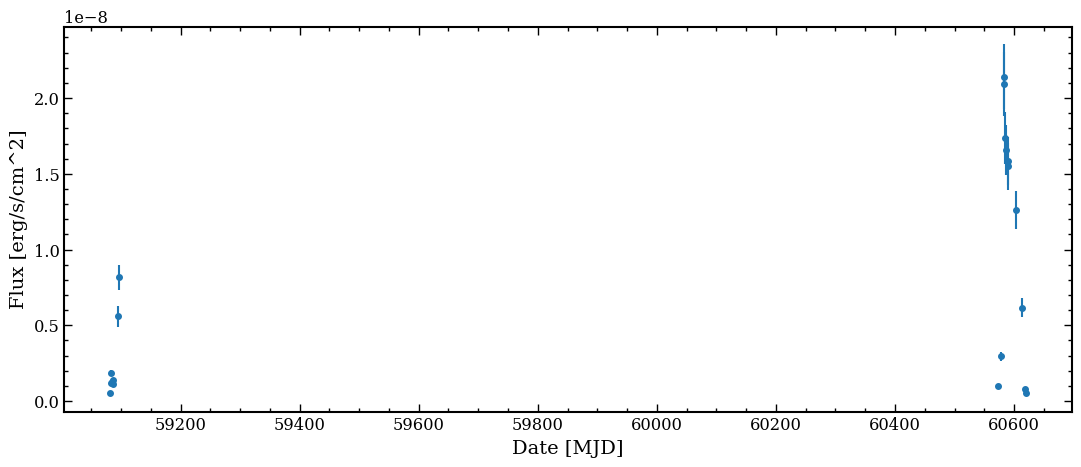

In [10]:
plot_xray_lightcurve(xray_df)

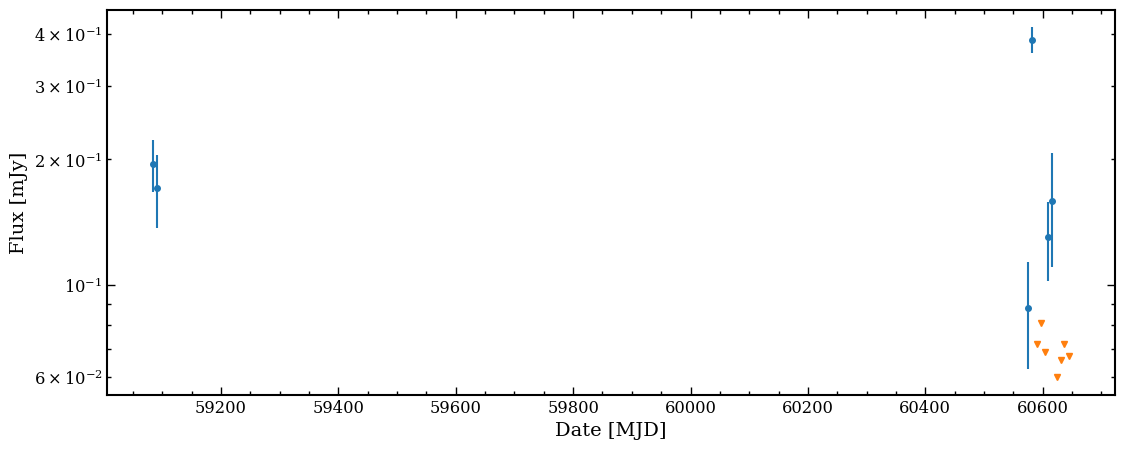

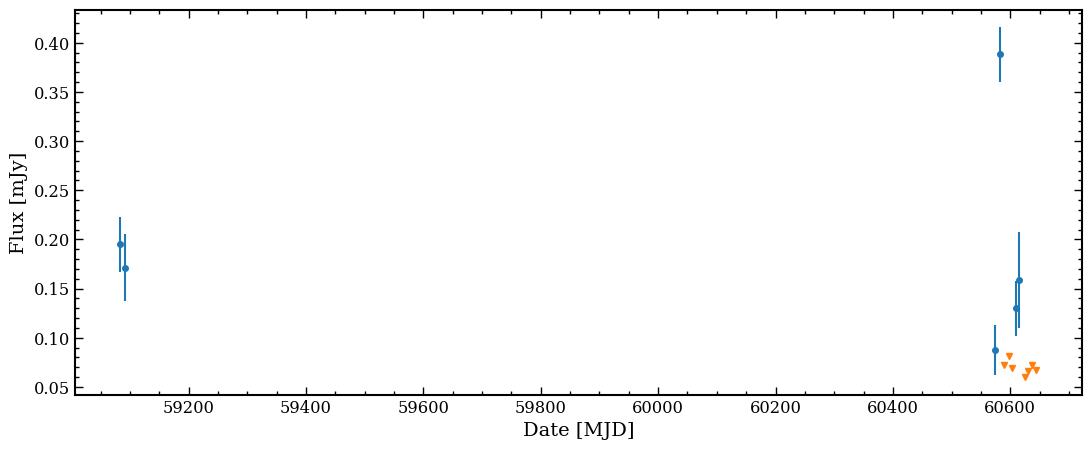

In [11]:
plot_radio_lightcurve(radio_df)

# Pairing

In [12]:
paired_data = make_paired_Lr_Lx_df(radio_df, xray_df, source_df)

t_radio             Fr [mJy]            Fr_unc [mJy]        #xray     t_diff                        Mean Fx [erg/cm^2/s]          Fx_unc_l[erg/cm^2/s]          Fx_unc_u[erg/cm^2/s]          Fr_uplim_bool  Fx_uplim_bool  state          
59083.925350000     0.19500             0.02777             1         [0.029]                       1.86400e-09                   1.87002e-10                   1.87015e-10                   False          False          HS             
60582.560810000     0.38800             0.02786             2         [0.185 0.416]                 2.11650e-08                   1.49969e-09                   1.50003e-09                   False          False          IMS            
60589.541250000     0.07200             0.02400             2         [0.634 0.329]                 1.56765e-08                   1.11011e-09                   1.11006e-09                   True           False          SS             
Converting to luminosity using d_kpc = 6


In [15]:
paired_data[["t", "Fr", "Fr_unc", "Fx", "Fx_unc_l", "Fx_unc_u", "state"]]

,t,Fr,Fr_unc,Fx,Fx_unc_l,Fx_unc_u,state
0,59083.92535,0.195,0.027768,1.864000e-09,1.870018e-10,1.870147e-10,HS
1,60582.56081,0.388,0.027863,2.116499e-08,1.499694e-09,1.500035e-09,IMS
2,60589.54125,0.072,0.024000,1.567649e-08,1.110111e-09,1.110059e-09,SS


In [16]:
lr_all, lx_all, all_types = get_bahramian_data()

Only including detections from Bahramian et al. data.
Converting Bahramian Lr values from 5 GHz to 1.28 GHz, assuming flat spectral index.


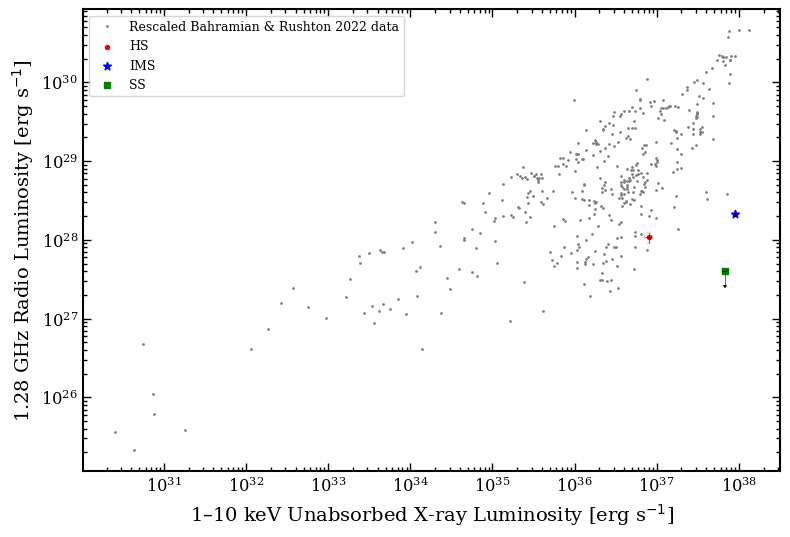

In [17]:
plot_Lr_Lx(paired_data, colourby="state", lx=lx_all, lr=lr_all)

# Interpolation

dt1, dt2:  3.0 10.0

Number of plotting points:  3076
59083.92535: time_to_nearest: 0.029470000001310837 & time_to_furthest: 1.103530000000319; y_predict_err: 0.04465320281511431
59091.70035: time_to_nearest: 2.738920000003418 & time_to_furthest: 4.76252999999997; y_predict_err: 0.050898520666486036
60574.59674: time_to_nearest: 1.623650000001362 & time_to_furthest: 3.7898199999981443; y_predict_err: 0.03979479428248567
60582.56081: time_to_nearest: 0.1854800000000978 & time_to_furthest: 4.174250000003667; y_predict_err: 0.0594886393573022
60589.54125: time_to_nearest: 0.3294999999998254 & time_to_furthest: 0.6340200000049663; y_predict_err: 0.03527923646911102
Rejected based on distance: radio_MJD = 60597.54484; time_to_nearest: 4.903189999997267; time_to_furthest: 7.674090000000433
60603.56631: time_to_nearest: 1.1182800000024145 & time_to_furthest: 9.650679999998829; y_predict_err: 0.04728308134870485
Rejected based on distance: radio_MJD = 60609.55559; time_to_nearest: 3.6613999999

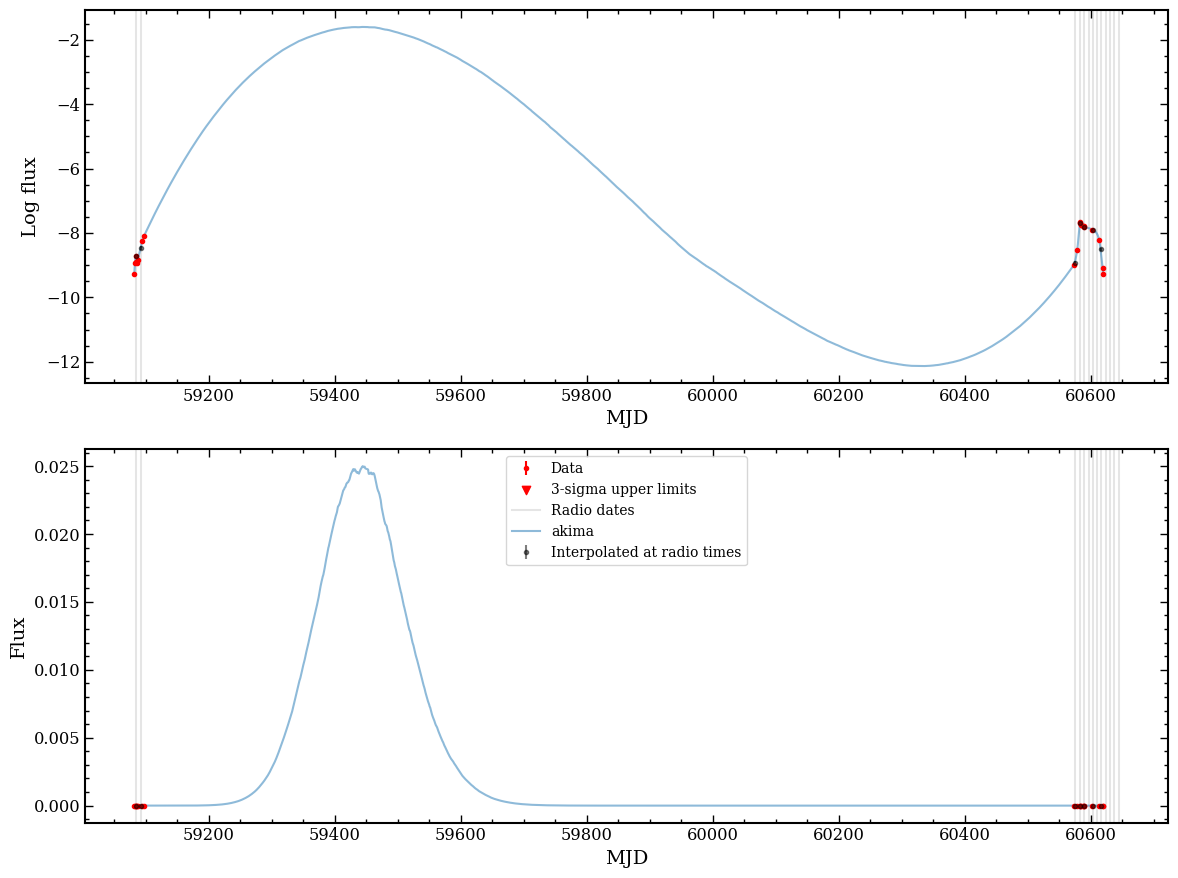

Number of used interpolated data points:  7
Converting to luminosity using d_kpc = 6


In [18]:
interpolated_data = make_interpolated_Lr_Lx_df(radio_df, xray_df, source_df, plotly=True)

In [21]:
interpolated_data[["t", "state", "Fr", "Fx"]]

,t,state,Fr,Fx
0,59083.92535,HS,0.195,1.858500e-09
1,59091.70035,HS,0.171,3.434778e-09
2,60574.59674,HS,0.088,1.202350e-09
3,60582.56081,IMS,0.388,1.986289e-08
4,60589.54125,SS,0.072,1.560917e-08
5,60603.56631,SS,0.069,1.227981e-08
6,60615.48348,IMS,0.159,3.105498e-09


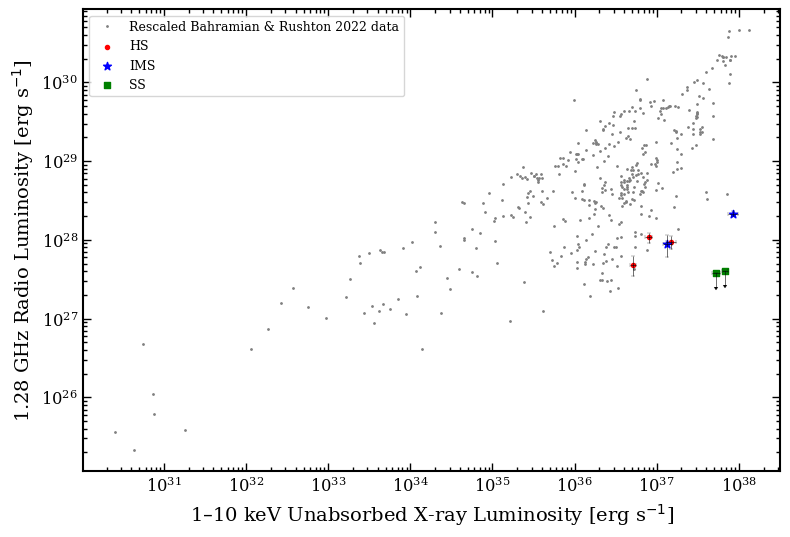

In [20]:
plot_Lr_Lx(interpolated_data, colourby="state", lx=lx_all, lr=lr_all)